# Кейс 7. Аддитивная модель по мотивам теоремы Колмогорова

## 1. Импорты

In [1]:
import sys
import pathlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, HTML

from sklearn.datasets import fetch_california_housing, load_diabetes
from sklearn.model_selection import train_test_split

PROJECT_ROOT = pathlib.Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from shared.metrics import rmse, r2_score
from shared.utils import min_max_scale
from case_7.src.additive import AdditiveModel, FullNonLinearModel

## 2. Генерация синтетических данных

In [2]:
np.random.seed(42)
N = 300
X_add = np.random.uniform(0, 1, size=(N, 3))
# y = sin(2*pi*x1) + 0.5*(x2 - 0.5)^2 + exp(-3*x3) + eps
y_add = np.sin(2 * np.pi * X_add[:, 0]) + 0.5 * (X_add[:, 1] - 0.5)**2 + np.exp(-3 * X_add[:, 2]) + np.random.normal(0, 0.1, N)

X_nonadd = np.random.uniform(0, 1, size=(N, 3))
# Неаддитивная зависимость
y_nonadd = np.sin(2 * np.pi * (X_nonadd[:, 0] + X_nonadd[:, 1])) + 0.5 * X_nonadd[:, 2] + np.random.normal(0, 0.1, N)

## 3. Обучение аддитивной модели и интерпретация компонент

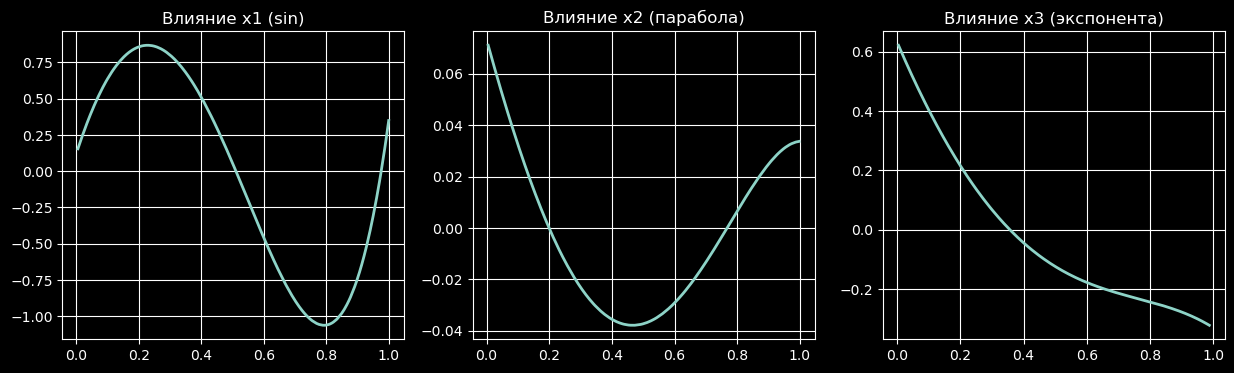

In [3]:
# Обучение модели с полиномиальным базисом
add_model = AdditiveModel(M=5, basis='poly', alpha=0.01).fit(X_add, y_add)

# Извлекаем функции g_j(x)
X_test_sorted = np.sort(X_add, axis=0) # сортируем для графиков
_, components = add_model.predict_components(X_test_sorted)

plt.figure(figsize=(15, 4))
titles = ["Влияние x1 (sin)", "Влияние x2 (парабола)", "Влияние x3 (экспонента)"]
for j in range(3):
    plt.subplot(1, 3, j+1)
    plt.plot(X_test_sorted[:, j], components[j], linewidth=2)
    plt.title(titles[j])
    plt.grid(True)
plt.show()

## 4. Сравнение с Линейной и Полной Нелинейной моделями

In [4]:
def eval_model(model, X, y):
    preds = model.predict(X)
    return rmse(y, preds), r2_score(y, preds)

In [5]:
# Подготовка Diabetes (нормализация признаков в [0, 1])
diabetes = load_diabetes()
X_db_scaled = min_max_scale(diabetes.data)
y_db = diabetes.target
X_tr_db, X_te_db, y_tr_db, y_te_db = train_test_split(X_db_scaled, y_db, test_size=0.2, random_state=42)

# Обучение трех моделей на Diabetes
db_lin = AdditiveModel(M=1, basis='poly').fit(X_tr_db, y_tr_db)
db_add = AdditiveModel(M=3, basis='poly', alpha=0.1).fit(X_tr_db, y_tr_db)
db_full = FullNonLinearModel(degree=2, alpha=0.1).fit(X_tr_db, y_tr_db) # Степень 2 для стабильности на 10 признаках

# Подготовка California Housing
housing = fetch_california_housing()
X_hs_scaled = min_max_scale(housing.data)
y_hs = housing.target
X_tr_hs, X_te_hs, y_tr_hs, y_te_hs = train_test_split(X_hs_scaled, y_hs, test_size=0.2, random_state=42)

# Обучение трех моделей на California Housing
hs_lin = AdditiveModel(M=1, basis='poly').fit(X_tr_hs, y_tr_hs)
hs_add = AdditiveModel(M=3, basis='poly', alpha=0.1).fit(X_tr_hs, y_tr_hs)
hs_full = FullNonLinearModel(degree=2, alpha=0.1).fit(X_tr_hs, y_tr_hs)

# Сбор результатов
df_real_db = pd.DataFrame({
    "Модель": ["Линейная", "Аддитивная", "Полная нелинейная (deg=2)"],
    "RMSE": [eval_model(db_lin, X_te_db, y_te_db)[0], eval_model(db_add, X_te_db, y_te_db)[0], eval_model(db_full, X_te_db, y_te_db)[0]],
    "R^2": [eval_model(db_lin, X_te_db, y_te_db)[1], eval_model(db_add, X_te_db, y_te_db)[1], eval_model(db_full, X_te_db, y_te_db)[1]]
})

df_real_hs = pd.DataFrame({
    "Модель": ["Линейная", "Аддитивная", "Полная нелинейная (deg=2)"],
    "RMSE": [eval_model(hs_lin, X_te_hs, y_te_hs)[0], eval_model(hs_add, X_te_hs, y_te_hs)[0], eval_model(hs_full, X_te_hs, y_te_hs)[0]],
    "R^2": [eval_model(hs_lin, X_te_hs, y_te_hs)[1], eval_model(hs_add, X_te_hs, y_te_hs)[1], eval_model(hs_full, X_te_hs, y_te_hs)[1]]
})

display(HTML("<h3>Метрики моделей на реальном датасете: Diabetes</h3>"))
display(df_real_db.style.format({"RMSE": "{:.4f}", "R^2": "{:.4f}"}).hide(axis="index"))

display(HTML("<h3>Метрики моделей на реальном датасете: California Housing</h3>"))
display(df_real_hs.style.format({"RMSE": "{:.4f}", "R^2": "{:.4f}"}).hide(axis="index"))

Модель,RMSE,R^2
Линейная,53.8534,0.4526
Аддитивная,52.7004,0.4758
Полная нелинейная (deg=2),50.6527,0.5157


Модель,RMSE,R^2
Линейная,0.7456,0.5758
Аддитивная,0.7169,0.6079
Полная нелинейная (deg=2),0.7118,0.6133
